In [1]:
import kagglehub
import os
from pathlib import Path
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Download dataset
path = kagglehub.dataset_download("akashrayhan/yoga-82")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\marti\.cache\kagglehub\datasets\akashrayhan\yoga-82\versions\1


In [3]:
# Number of classes

def count_classes_and_samples(path: Path):
    samples = 0
    for entry in path.iterdir():
        if not entry.is_dir():
            continue
        class_samples = count_folders(entry)
        samples += class_samples
    classes = count_folders(path)
    return samples, classes

def count_folders(path):
    return sum(1 for _ in path.iterdir())

path = Path(path)

for set in ['train', 'test', 'valid']:    
    samples, classes = count_classes_and_samples(path / set)
    print(f'{set} size: {samples}, classes: {classes}')

train size: 11652, classes: 82
test size: 1764, classes: 82
valid size: 3351, classes: 82


In [4]:
# Image resolution stats

VALID_EXT = {".jpg", ".jpeg"}

def iter_images(split_path: Path):
    for class_dir in split_path.iterdir():
        if not class_dir.is_dir():
            continue

        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in VALID_EXT:
                yield img_path


def get_image_size(img_path: Path):
    with Image.open(img_path) as img:
        return img.size  # (w, h)


def compute_split_stats(split_path: Path):
    widths, heights = [], []

    for img_path in iter_images(split_path):
        try:
            w, h = get_image_size(img_path)
            widths.append(w)
            heights.append(h)
        except Exception:
            continue

    if not widths:
        return None

    widths = np.array(widths)
    heights = np.array(heights)

    return {
        "count": len(widths),
        "min_width": int(widths.min()),
        "max_width": int(widths.max()),
        "avg_width": float(widths.mean()),
        "min_height": int(heights.min()),
        "max_height": int(heights.max()),
        "avg_height": float(heights.mean()),
    }

# ---- main ----

path = Path(path)

for split in ["train", "valid", "test"]:
    stats = compute_split_stats(path / split)

    print(f"\n=== {split.upper()} ===")
    if stats is None:
        print("No images found.")
        continue

    print(f"Images: {stats['count']}")
    print(f"Width : min={stats['min_width']}, max={stats['max_width']}, avg={stats['avg_width']:.1f}")
    print(f"Height: min={stats['min_height']}, max={stats['max_height']}, avg={stats['avg_height']:.1f}")

c:\Users\marti\Documents\University\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))



=== TRAIN ===
Images: 11652
Width : min=1, max=6240, avg=744.3
Height: min=1, max=5244, avg=622.4

=== VALID ===
Images: 3351
Width : min=53, max=6016, avg=760.8
Height: min=49, max=5184, avg=633.4

=== TEST ===
Images: 1764
Width : min=1, max=6016, avg=776.8
Height: min=1, max=4000, avg=618.1


In [5]:
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(path / "train", transform=transform)
val_ds   = datasets.ImageFolder(path / "valid", transform=transform)
test_ds  = datasets.ImageFolder(path / "test", transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(train_ds.classes)
print("Classes:", num_classes)

Classes: 82


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device to be used: ", device)

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

Device to be used:  cuda


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [8]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            preds = out.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return correct / total, all_preds, all_labels

In [9]:
EPOCHS = 5  # baseline only

for epoch in range(EPOCHS):
    loss = train_one_epoch(model, train_loader)
    acc, _, _ = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}: loss={loss:.4f}, val_acc={acc:.4f}")

Epoch 1: loss=3.3809, val_acc=0.5210
Epoch 2: loss=1.5513, val_acc=0.7189
Epoch 3: loss=0.8959, val_acc=0.7848
Epoch 4: loss=0.5790, val_acc=0.8087
Epoch 5: loss=0.3879, val_acc=0.8248


In [10]:
acc, preds, labels = evaluate(model, test_loader)

print("Test accuracy:", acc)

print("\nClassification report:")
print(classification_report(labels, preds, target_names=test_ds.classes))

cm = confusion_matrix(labels, preds)
print("\nConfusion matrix shape:", cm.shape)

Test accuracy: 0.8327664399092971

Classification report:
                                                                           precision    recall  f1-score   support

                                                       Akarna_Dhanurasana       0.80      0.89      0.84         9
                              Bharadvajas_Twist_pose_or_Bharadvajasana_I_       0.33      0.22      0.27         9
                                         Boat_Pose_or_Paripurna_Navasana_       0.94      0.94      0.94        31
                                     Bound_Angle_Pose_or_Baddha_Konasana_       0.96      0.88      0.92        26
                                                 Bow_Pose_or_Dhanurasana_       0.92      1.00      0.96        23
                                 Bridge_Pose_or_Setu_Bandha_Sarvangasana_       0.90      0.96      0.93        28
                                                 Camel_Pose_or_Ustrasana_       0.92      0.97      0.94        34
                     

In [11]:
report = classification_report(labels, preds, target_names=test_ds.classes, output_dict=True)

weak_classes = sorted(
    [(k, v["f1-score"]) for k, v in report.items() if k in test_ds.classes],
    key=lambda x: x[1]
)

print("Worst classes:")
print(weak_classes[:10])

Worst classes:
[('Dolphin_Pose_or_Ardha_Pincha_Mayurasana_', 0.25), ('Wide-Angle_Seated_Forward_Bend_pose_or_Upavistha_Konasana_', 0.2564102564102564), ('Bharadvajas_Twist_pose_or_Bharadvajasana_I_', 0.26666666666666666), ('Cockerel_Pose', 0.3157894736842105), ('Dolphin_Plank_Pose_or_Makara_Adho_Mukha_Svanasana_', 0.3333333333333333), ('Noose_Pose_or_Pasasana_', 0.3333333333333333), ('Scorpion_pose_or_vrischikasana', 0.4444444444444444), ('Standing_Split_pose_or_Urdhva_Prasarita_Eka_Padasana_', 0.5714285714285714), ('Tortoise_Pose', 0.5806451612903226), ('Fish_Pose_or_Matsyasana_', 0.5957446808510638)]


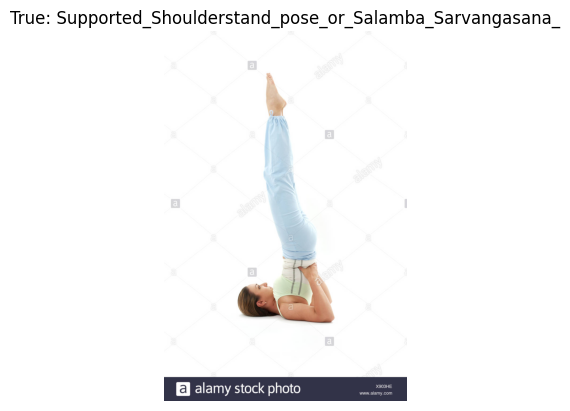

Predicted : Supported_Shoulderstand_pose_or_Salamba_Sarvangasana_ (98.8%)
True label: Supported_Shoulderstand_pose_or_Salamba_Sarvangasana_
Correct   : True


In [15]:
import random
import matplotlib.pyplot as plt

random.seed(42)

img_path, true_idx = random.choice(val_ds.samples)
true_label = val_ds.classes[true_idx]

img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.title(f"True: {true_label}")
plt.axis("off")
plt.show()

img_tensor = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    out = model(img_tensor)
    pred_idx = out.argmax(dim=1).item()
    confidence = torch.softmax(out, dim=1)[0, pred_idx].item()

pred_label = val_ds.classes[pred_idx]
print(f"Predicted : {pred_label} ({confidence:.1%})")
print(f"True label: {true_label}")
print(f"Correct   : {pred_label == true_label}")

In [16]:
import torch.nn.functional as F
from tqdm import tqdm

def extract_features(imgs):
    feats = model.features(imgs)
    feats = model.avgpool(feats)
    return torch.flatten(feats, 1)

# Use a loader without shuffle so indices align with train_ds.samples
index_loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=2)

train_embeddings = []
model.eval()
with torch.no_grad():
    for x, _ in tqdm(index_loader, desc="Indexing train set"):
        train_embeddings.append(extract_features(x.to(device)).cpu())

train_embeddings = torch.cat(train_embeddings, dim=0)
train_embeddings = F.normalize(train_embeddings, dim=1)
print(f"Index shape: {train_embeddings.shape}")

Indexing train set: 100%|██████████| 183/183 [00:33<00:00,  5.41it/s]

Index shape: torch.Size([11652, 1280])


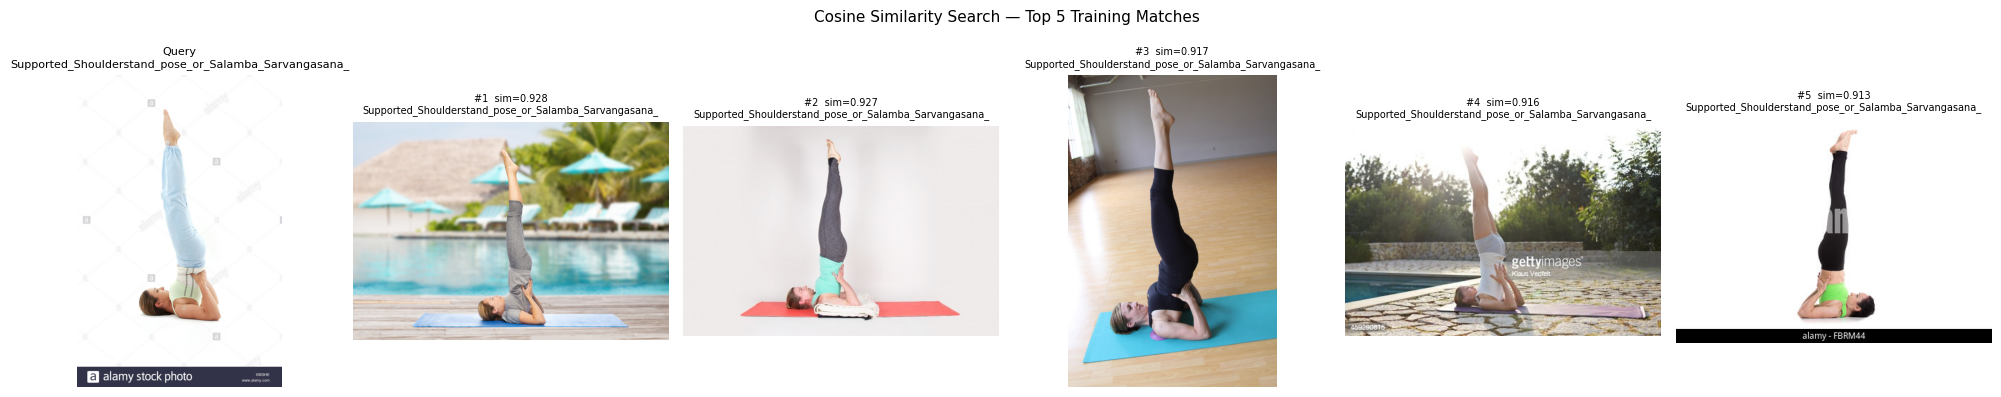

In [17]:
with torch.no_grad():
    query_emb = F.normalize(extract_features(img_tensor.to(device)).cpu(), dim=1)

sims = (train_embeddings @ query_emb.T).squeeze()
top5 = sims.topk(5)

fig, axes = plt.subplots(1, 6, figsize=(20, 4))

axes[0].imshow(img)
axes[0].set_title(f"Query\n{true_label}", fontsize=8)
axes[0].axis("off")

for i, (idx, score) in enumerate(zip(top5.indices, top5.values)):
    match_path, match_class_idx = train_ds.samples[idx.item()]
    match_label = train_ds.classes[match_class_idx]
    match_img = Image.open(match_path).convert("RGB")
    axes[i + 1].imshow(match_img)
    axes[i + 1].set_title(f"#{i+1}  sim={score:.3f}\n{match_label}", fontsize=7)
    axes[i + 1].axis("off")

plt.suptitle("Cosine Similarity Search — Top 5 Training Matches", fontsize=11)
plt.tight_layout()
plt.show()